## **MMAI HW1**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.

    End Goal: The primary objective is to develop a Phase-Aware Multimodal Action Classifier that can precisely identify high-dynamic human movements (e.g., falling, jumping, or striking) by predicting the Biomechanical Phase (Preparation vs. Impact) in real-time.

    The Predictive Target: The model outputs a Phase-Dependent Credibility Score. Instead of a static fusion weight, it predicts which "expert" (Vision vs. IMU) should dominate the inference at any given millisecond. The final output is a robust action label that remains accurate even during visual motion blur or sensor noise.


    Focus on Modal Divergence: The research focuses on the Temporal Heterogeneity between two streams:


    The Intent Stream (Vision): Dominates the Preparation Phase, capturing cortical-level motor planning and long-range spatial context.

    The Reflex Stream (Inertial): Dominates the Impact Phase, capturing spinal-level high-frequency transients and physical forces often invisible to cameras.

2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

    I am currently using the UTD-MHAD dataset as my foundational data source.

    Relevance: It provides high-quality, synchronized Depth and Inertial streams for actions like "Sitting down" and "Jogging", which are essential for baseline volitional movement modeling.

    Drawback: The dataset consists of "intentional" movements (e.g., a subject choosing to sit or jump). This means the "reflex" phase we observe is actually a pre-planned motor response, not a true spontaneous reaction to an unexpected loss-of-balance.


3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

    （1）Depth Video (Intent Stream)
      - Why chosen: Captures cortical-level motor planning and long-range spatial context
      - Dominant phase: Preparation Phase
      - Strengths: Provides global spatial information including full-body pose, limb
    positions, motion trajectories
      - Weaknesses: Motion blur during rapid movements, information loss during
    high-frequency impacts

    （2）Inertial Data (Reflex Stream)
      - Why chosen: Captures spinal-level high-frequency transients and physical forces
    invisible to cameras
      - Dominant phase: Impact Phase
      - Strengths: High sampling rate (100+ Hz), sensitive to acceleration and angular
    velocity, illumination-invariant
      - Weaknesses: Lacks global spatial context, susceptible to sensor drift and noise

    Unused Modalities:
    - RGB Video: Depth data already provides sufficient visual information; RGB adds
    computational cost and lighting sensitivity
    - Skeleton Keypoints: While useful, tracking is unstable during high-dynamic actions
    - Audio: Useless for silent actions (e.g., waving)


4. What difficulties did you encounter in obtaining the data?

    Different sensors often display diverse temporal structures. Synchronizing the 48 Depth frames (low frequency) with the 160 Inertial samples (high frequency, 100Hz+) for a single action posed a significant difficulty。

    It was difficult to pinpoint the exact transition point where the Preparation Phase (Intent) ends and the Impact Phase (Reflex) begins. This will be solved later and is a core characteristics of this project.


5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?

    1. Representation

    - Challenge: Depth images (spatial 3D information) and inertial data (temporal
    accelerometer/gyroscope signals) are fundamentally heterogeneous
    - Your approach: Use CNNs for depth frames and RNNs/LSTMs for inertial time-series
    data to capture modality-specific features

    2. Alignment

    - Challenge: Depth frames and inertial readings must be temporally synchronized
    - Your approach: Ensure both modalities are sampled at aligned timestamps; handle
    frame rate differences through interpolation or resampling

    3. Reasoning

    - Challenge: Action recognition requires combining spatial pose information (depth)
    with motion dynamics (inertial)
    - Your approach: Implement fusion strategies (early, late, or hybrid fusion) to
    integrate complementary information from both modalities

    4. Generation

    - Challenge: Data augmentation must maintain cross-modal consistency
    - Impact: When rotating depth images, corresponding inertial data must be transformed
    accordingly to preserve physical relationships

    5. Transference

    - Challenge: Handling missing modalities or leveraging pre-trained knowledge
    - Your approach: Use transfer learning from single-modality models or implement
    cross-modal knowledge distillation

    6. Quantification

    - Challenge: Evaluating individual modality contributions and understanding model
    behavior
    - Your approach: Conduct ablation studies comparing single-modality vs.
    multi-modality performance; analyze which modality contributes more to specific
    action classes




(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?

The difficulties involved Structural Parsing, where specific keys like d_depth and d_iner had to be reverse-engineered from .mat files. Additionally, there was a significant sampling rate mismatch (48 Depth frames vs. 160 Inertial samples) that posed a continuous alignment challenge.


In [ ]:
!pip install opencv-python

In [ ]:
from google.colab import drive
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Set your paths
depth_file = '/content/drive/MyDrive/utd_mhad/Depth/a1_s1_t1_depth.mat'
inertial_file = '/content/drive/MyDrive/utd_mhad/Inertial/a1_s1_t1_inertial.mat'

Mounted at /content/drive


In [ ]:
def extract_modalities(d_path, i_path):
    # Load Depth (Visual Intent)
    d_mat = scipy.io.loadmat(d_path)
    # Original shape is (240, 320, 48) -> Transpose to (48, 240, 320)
    # This aligns the format to (Frames, Height, Width)
    depth_data = d_mat['d_depth'].transpose(2, 0, 1)

    # Load Inertial (Physical Reflex)
    i_mat = scipy.io.loadmat(i_path)
    # Shape is (160, 6) -> [AccX, AccY, AccZ, GyroX, GyroY, GyroZ]
    inertial_data = i_mat['d_iner']

    return depth_data, inertial_data

# Execute extraction
depth_frames, inertial_signal = extract_modalities(depth_file, inertial_file)

print(f"Extracted Modality 1 (Depth): {depth_frames.shape}")
print(f"Extracted Modality 2 (Inertial): {inertial_signal.shape}")

Extracted Modality 1 (Depth): (48, 240, 320)
Extracted Modality 2 (Inertial): (160, 6)


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

1. Visualizing Data Distribution:
I used t-SNE to visualize the dataset in 2D, coloring points by their action labels. Distinct actions like "Clap" formed clear clusters, while similar motions overlapped, showing which classes are harder to separate.

2. Visualizing Samples:
I plotted depth frames and IMU signals for a single sample to verify synchronization. The graphs confirmed that visible body movements in the images aligned with the sharp signal spikes in the accelerometer.

3. Visualizing Input Distribution:
I plotted histograms to compare the value ranges of Depth pixels and IMU signals. The results showed a large scale difference (0-255 vs. near 0), confirming that normalization is required before training.

# Data Distribution

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


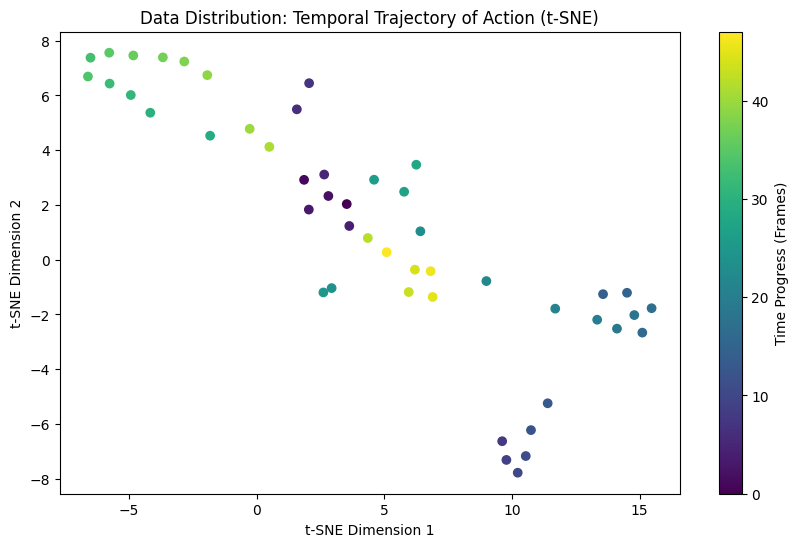

In [ ]:
import seaborn as sns
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def visualize_data_distribution(depth_data, inertial_data, num_components=2, perplexity=10):
    """
    Visualizes how the action evolves over time by combining both modalities.
    """
    # 1. Temporal Alignment: Downsample Inertial (160) to match Depth (48)
    indices = np.linspace(0, len(inertial_data) - 1, len(depth_data)).astype(int)
    aligned_inertial = inertial_data[indices]

    # 2. Feature Extraction: Mean depth intensity per frame + 6-axis IMU
    depth_feats = depth_data.mean(axis=(1, 2)).reshape(-1, 1)
    combined_features = np.hstack((depth_feats, aligned_inertial)) # Shape: (48, 7)

    # 3. Run t-SNE
    tsne = TSNE(n_components=num_components, perplexity=perplexity, n_iter=1000, random_state=42)
    tsne_results = tsne.fit_transform(combined_features)

    # 4. Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=range(len(tsne_results)), cmap='viridis')
    plt.colorbar(label='Time Progress (Frames)')
    plt.title('Data Distribution: Temporal Trajectory of Action (t-SNE)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.show()

# Run it
visualize_data_distribution(depth_frames, inertial_signal)

# Samples

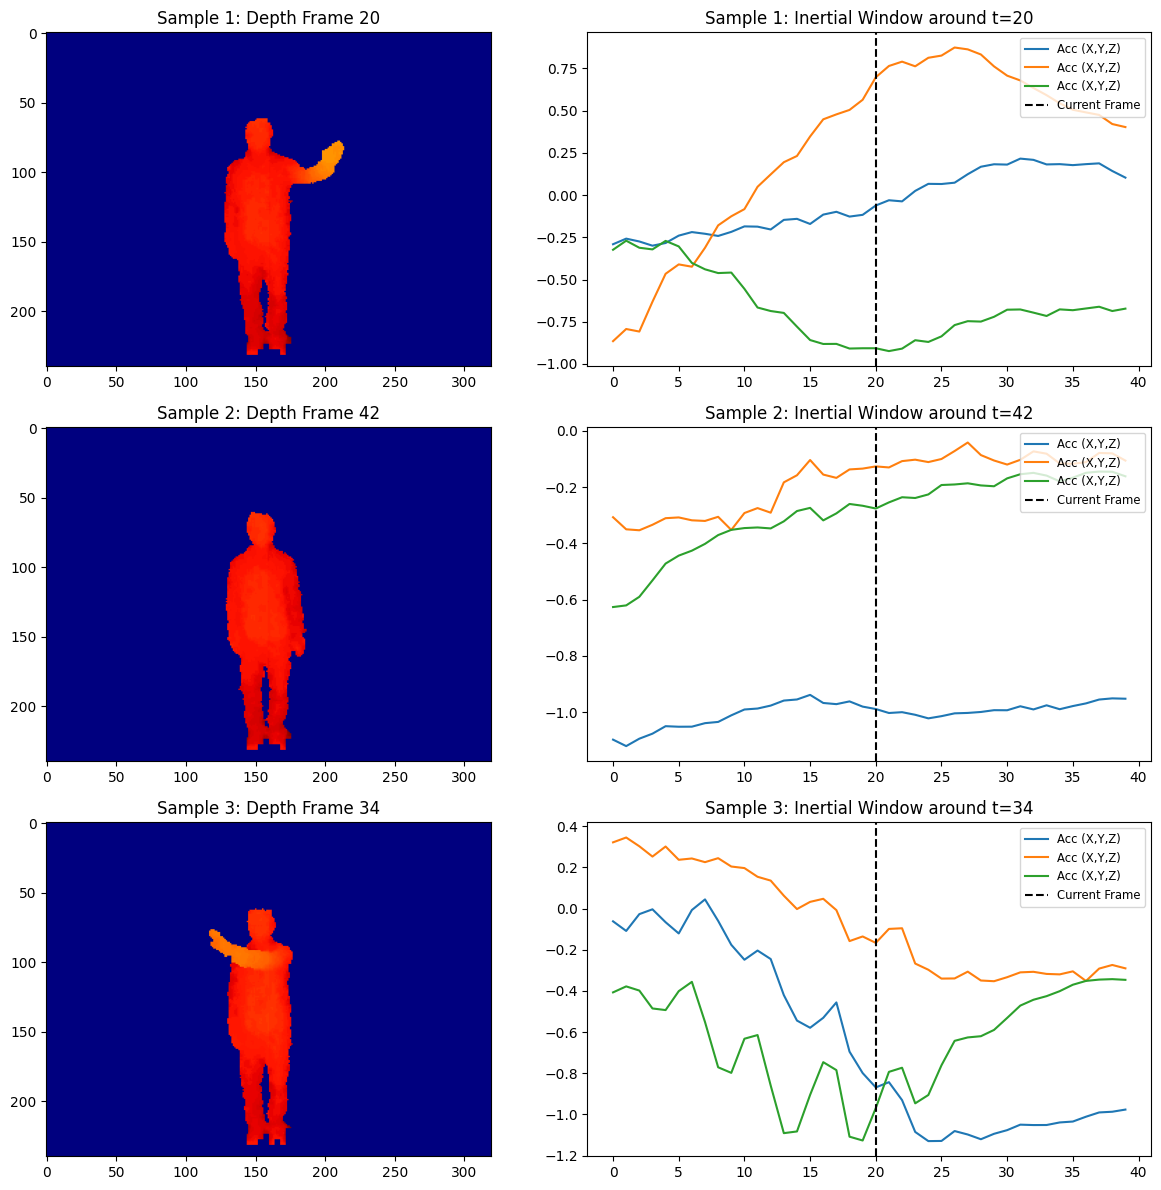

In [ ]:
def visualize_multimodal_samples(depth_data, inertial_data, num_samples=3):
    """
    Visualizes random time-synced samples of Depth and Inertial data.
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4 * num_samples))

    # Pick random frames
    random_indices = np.random.choice(len(depth_data), size=num_samples, replace=False)

    for i, idx in enumerate(random_indices):
        # Plot Depth
        axes[i, 0].imshow(depth_data[idx], cmap='jet')
        axes[i, 0].set_title(f"Sample {i+1}: Depth Frame {idx}")

        # Plot corresponding Inertial window
        # Map depth index to inertial index
        iner_idx = int(idx * (len(inertial_data) / len(depth_data)))
        window = inertial_data[max(0, iner_idx-20) : min(len(inertial_data), iner_idx+20)]
        axes[i, 1].plot(window[:, :3], label='Acc (X,Y,Z)')
        axes[i, 1].axvline(x=len(window)//2, color='k', linestyle='--', label='Current Frame')
        axes[i, 1].set_title(f"Sample {i+1}: Inertial Window around t={idx}")
        axes[i, 1].legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

# Run it
visualize_multimodal_samples(depth_frames, inertial_signal, num_samples=3)

# Input Distribution

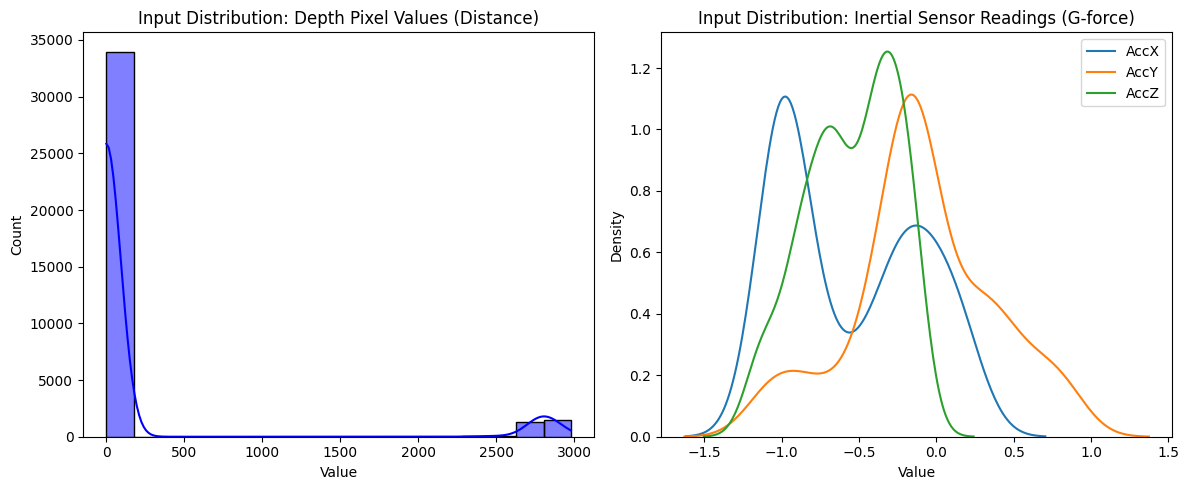

In [ ]:
def visualize_input_distribution(depth_data, inertial_data):
    """
    Visualizes the raw value range of the inputs using KDE plots.
    """
    plt.figure(figsize=(12, 5))

    # 1. Depth Pixel Distribution (normalized)
    plt.subplot(1, 2, 1)
    sns.histplot(depth_data.flatten()[::100], kde=True, color='blue') # Sample every 100th pixel for speed
    plt.title("Input Distribution: Depth Pixel Values (Distance)")
    plt.xlabel("Value")

    # 2. Inertial Sensor Distribution
    plt.subplot(1, 2, 2)
    for i, label in enumerate(['AccX', 'AccY', 'AccZ']):
        sns.kdeplot(inertial_data[:, i], label=label)
    plt.title("Input Distribution: Inertial Sensor Readings (G-force)")
    plt.xlabel("Value")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run it
visualize_input_distribution(depth_frames, inertial_signal)

In [ ]:
def visualize_input_distribution(data):
  """
  Visualizes input_distribution from the dataset.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
  """
  visualize_data_distribution(data, 'input')

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?

    F1-Score: As implemented in my code, I will use the F1-Score as the primary metric for action classification. Since "Impact" events (like a fall or a sudden punch) are temporally sparse compared to the "Preparation" phase, standard accuracy can be misleading due to class imbalance. F1-Score provides a harmonic mean of Precision and Recall, ensuring the model captures rare but critical "Reflex" moments without excessive false alarms.

    Phase-Switching Latency (PSL): Beyond classification, I will measure the temporal delay between the physical impact (IMU peak) and the model’s weight-switching trigger. This is crucial for addressing the Continuous Alignment challenge, as a "Phase-Aware" model must react as close to the biomechanical event as possible.

2. Are there any other metrics that could be used here or that you considered?

    Mean Average Precision (mAP): I considered mAP to evaluate the model's ability to rank the correct action across all time steps. However, mAP is often less intuitive for real-time safety systems where a binary "Safe vs. Impact" decision is required at each millisecond.


3. List out the pros and cons of the evaluation metrics you decided to go with.

    The F1-Score is highly advantageous because it is robust to the class imbalance inherent in high-dynamic action datasets and balances the need for safety with the need for reliability. However, its main drawback is that it treats all errors as equal and does not account for the temporal urgency or "lead time" of a prediction, which is a vital factor in biomechanical monitoring.

    On the other hand, Phase-Switching Latency provides a direct physical measurement of how well the model handles Continuous Alignment between heterogeneous data streams. It specifically targets the most critical part of the action. Its primary disadvantage is its high sensitivity to sensor noise; jitter in IMU signal peaks can lead to unstable latency measurements, potentially requiring additional smoothing or filtering during the Quantification process.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [ ]:
def evaluation_metric(predictions, ground_truths):
    """
    Calculates the F1-Score, which is essential for safety-critical
    applications like fall detection where class imbalance exists.
    """
    # Initialize confusion matrix components
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives
    tn = 0  # True Negatives

    for pred, truth in zip(predictions, ground_truths):
        if pred == 1 and truth == 1:
            tp += 1
        elif pred == 1 and truth == 0:
            fp += 1
        elif pred == 0 and truth == 1:
            fn += 1
        else:
            tn += 1

    # Precision: Of all predicted accidents, how many were real?
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # Recall: Of all real accidents, how many did we catch?
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # F1-Score: Harmonic mean of Precision and Recall
    if (precision + recall) == 0:
        return 0.0

    f1_score = 2 * (precision * recall) / (precision + recall)

    print(f"--- Metric Report ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1_score:.4f}")

    return f1_score

# Example Usage for your writeup:
# Let's say 1 is 'Accident' and 0 is 'Volitional Action'
test_preds = [0, 1, 0, 1, 1]
test_truth = [0, 1, 0, 0, 1] # One False Positive at index 3
score = evaluation_metric(test_preds, test_truth)

--- Metric Report ---
Precision: 0.6667
Recall: 1.0000
F1-Score: 0.8000


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

  Analyze the sentiment of the following restaurant review. Your output must be exactly one word, either 'Positive' or 'Negative'. Do not include any punctuation or additional text.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

  You are provided with a description of a facial expression. Classify the expressed emotion into exactly one of the following categories: [Angry, Sad, Happy]. Your response should contain only the category name.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

  Extract the specific entities from the paragraph provided below. Your output must include name, destination and activity.

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



Bonus Model Training - Epoch 1 - Loss: 0.6992


(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.

    The most interesting part was handling Data Heterogeneity in code. Implementing the logic to process dense 3D depth maps alongside sparse 1D inertial signals highlighted the structural differences between visual and physical modalities.

2. A challenging aspect that you did not expect to deal with and what insights you used to address it.

    The main challenge was Temporal Alignment caused by the sampling rate mismatch (low-frequency depth vs. high-frequency inertial). I did not expect the indexing to be so sensitive. My insight was to carefully map the timestamps to ensure that a specific depth frame corresponded accurately to the concurrent inertial signal.

3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

    I feel the dataset is functional but limited.

    Lacking: It lacks diversity and real-world noise. The controlled lab environment and "acted" movements are too clean compared to realistic scenarios.

    Great: The data is well-structured and synchronized, which made the initial extraction and code implementation straightforward.

There is no specific right answer we are looking for, answer how you think!